In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # FEM builders
    build_elements,
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average,
    # Plotting — matplotlib
    plot_mesh, plot_field_2d, plot_deformed, plot_loads_2d, plot_gmsh_mesh,
    # Elements
    CST, LST, Quad4, Quad9,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m, mm,
    # Parameters
    globalParameters,
)

import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh

np.set_printoptions(suppress=True, precision=6, linewidth=400)


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. José Abell

  Version 1.1.0                        © 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen

  ********* (>'-')> Ladruño4ever  *********



In [3]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [4]:
# General model parameters
L = 5000 
H = 500  
B = 300
lc = 50
output_path = os.getcwd()
mesh_name = 'calibrated_beam'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [5]:
# Create a new GMSH model
gmsh.initialize()
gmsh.model.add(mesh_name)

# Corner points
p1 = gmsh.model.geo.addPoint(0,   0, 0, lc)
p2 = gmsh.model.geo.addPoint(L,   0, 0, lc)
p3 = gmsh.model.geo.addPoint(L,   H, 0, lc)
p4 = gmsh.model.geo.addPoint(0,   H, 0, lc)

# Mid points (bottom and top)
p5 = gmsh.model.geo.addPoint(L/2, 0, 0, lc)
p6 = gmsh.model.geo.addPoint(L/2, H, 0, lc)

# Lines
l1 = gmsh.model.geo.addLine(p1, p5)  # Bottom left
l2 = gmsh.model.geo.addLine(p5, p2)  # Bottom right
l3 = gmsh.model.geo.addLine(p2, p3)  # Right side
l4 = gmsh.model.geo.addLine(p3, p6)  # Top right
l5 = gmsh.model.geo.addLine(p6, p4)  # Top left
l6 = gmsh.model.geo.addLine(p4, p1)  # Left side
l7 = gmsh.model.geo.addLine(p5, p6)  # Center vertical

# Surfaces
c1 = gmsh.model.geo.addCurveLoop([l1,  l7, l5, l6])  # Left half
s1 = gmsh.model.geo.addPlaneSurface([c1])

c2 = gmsh.model.geo.addCurveLoop([l2, l3, l4, -l7])  # Right half
s2 = gmsh.model.geo.addPlaneSurface([c2])

gmsh.model.geo.synchronize()

# Physical groups
gmsh.model.addPhysicalGroup(2, [s1, s2], 201)
gmsh.model.setPhysicalName(2, 201, "Beam")

gmsh.model.addPhysicalGroup(0, [p1], 101)
gmsh.model.setPhysicalName(0, 101, "Support_left")

gmsh.model.addPhysicalGroup(0, [p2], 102)
gmsh.model.setPhysicalName(0, 102, "Support_right")

gmsh.model.addPhysicalGroup(0, [p6], 50)
gmsh.model.setPhysicalName(0, 50, "Load")

gmsh.model.geo.synchronize()

def all_quads():
    gmsh.model.geo.synchronize()
    gmsh.option.setNumber("Mesh.RecombineAll", 1)
    gmsh.option.setNumber("Mesh.Algorithm", 8)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
    gmsh.option.setNumber("Mesh.Smoothing", 100)
    gmsh.option.setNumber("Mesh.ElementOrder", 2)

# all_quads()

In [6]:
# Generate the mesh
gmsh.model.mesh.generate()
# Save mesh to disk
gmsh.write(output_file)
# Open GMSH GUI
gmsh.fltk.run()
# Write mesh file again (redundant)
v = gmsh.write(output_file)
# Close GMSH instance
gmsh.finalize()

In [7]:
# Define material
fc=210
fc_21 = Material(name='fc_21',
                 E=13500*fc**0.5*kgf/cm**2,
                 nu=0.20,
                 rho= 2400*kg/m**3*g*0)

# Define membrane section
ConcreteBeam = Membrane(name='ConcreteBeam',
                        thickness=300,
                        material=fc_21)

# Map physical group IDs to sections
section_dictionary = {201: ConcreteBeam}

# Define distributed load magnitude
Pload = 10*tf

load_dictionary = {
    50:  {'value': Pload, 'direction': '-y'},   
}

# Define boundary conditions (restraints)
restrain_dictionary = {101: ['r', 'r'],
                       102: ['f', 'r']}


In [8]:
# read mesh — node_map and system_nDof auto-generated
mesh = GMSHtools(output_file)

  MESH SUMMARY

  === NODES ===  (1316 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1         0.0000         0.0000         0.0000
       2      5000.0000         0.0000         0.0000
       3      5000.0000       500.0000         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (4 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
      50      0   'Load'
     101      0   'Support_left'
     102      0   'Support_right'
     201      2   'Beam'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (4 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
      50      0       15          1            1 

In [9]:
# Initialize nodes and apply Dirichlet (restraints) and Neumann (nodal loads) boundary conditions.
mesh.apply_boundary_conditions(restrain_dictionary, load_dictionary,verbose=True)


  === BOUNDARY CONDITIONS ===
  Nodes created  : 1316
  system_nDof    : 2632

  --- Restrained nodes ---
     Tag              x              y   Restraints
--------------------------------------------------------------------------------
       1         0.0000         0.0000   ['r', 'r']
       2      5000.0000         0.0000   ['f', 'r']
--------------------------------------------------------------------------------

  --- Loaded nodes (dim=0) ---
     Tag              x              y             Fx             Fy
--------------------------------------------------------------------------------
       6      2500.0000       500.0000        -0.0000    -98070.0000
--------------------------------------------------------------------------------



In [10]:
mesh.node_map

{1: Node 1 at [0. 0.],
 2: Node 2 at [5000.    0.],
 3: Node 3 at [5000.  500.],
 4: Node 4 at [  0. 500.],
 5: Node 5 at [2500.    0.],
 6: Node 6 at [2500.  500.],
 7: Node 7 at [50.  0.],
 8: Node 8 at [100.   0.],
 9: Node 9 at [150.   0.],
 10: Node 10 at [200.   0.],
 11: Node 11 at [250.   0.],
 12: Node 12 at [300.   0.],
 13: Node 13 at [350.   0.],
 14: Node 14 at [400.   0.],
 15: Node 15 at [450.   0.],
 16: Node 16 at [500.   0.],
 17: Node 17 at [550.   0.],
 18: Node 18 at [600.   0.],
 19: Node 19 at [650.   0.],
 20: Node 20 at [700.   0.],
 21: Node 21 at [750.   0.],
 22: Node 22 at [800.   0.],
 23: Node 23 at [850.   0.],
 24: Node 24 at [900.   0.],
 25: Node 25 at [950.   0.],
 26: Node 26 at [1000.    0.],
 27: Node 27 at [1050.    0.],
 28: Node 28 at [1100.    0.],
 29: Node 29 at [1150.    0.],
 30: Node 30 at [1200.    0.],
 31: Node 31 at [1250.    0.],
 32: Node 32 at [1300.    0.],
 33: Node 33 at [1350.    0.],
 34: Node 34 at [1400.    0.],
 35: Node 35

In [11]:
# por tag de gmsh
node = mesh.node_map[6]
print(node)

# o ver sus propiedades
node.print_summary()

Node 6 at [2500.  500.]

Node 6
  Coordinates : [2500.  500.]
  DOF indices : [10 11]
  Nodal load  : [    -0. -98070.]
  Restraints  : ['f' 'f']




In [12]:
mesh.elements

{50: {'dim': 0,
  'gmsh_type': 15,
  'n_nodes': 1,
  'element_tags': [3],
  'connectivity': [[6]]},
 101: {'dim': 0,
  'gmsh_type': 15,
  'n_nodes': 1,
  'element_tags': [1],
  'connectivity': [[1]]},
 102: {'dim': 0,
  'gmsh_type': 15,
  'n_nodes': 1,
  'element_tags': [2],
  'connectivity': [[2]]},
 201: {'dim': 2,
  'gmsh_type': 2,
  'n_nodes': 3,
  'element_tags': [4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
   88,
   89,
   90,
   91,
   92,
   93,
   94,


In [13]:
mesh.physical_groups["Beam"].elements


{'dim': 2,
 'gmsh_type': 2,
 'n_nodes': 3,
 'element_tags': [4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,


In [14]:
system_nDof = mesh.system_nDof
node_map = mesh.node_map

In [15]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

# build FEM elements
elements = build_elements(
    mesh               = mesh,
    node_map           = mesh.node_map,
    section_dictionary = section_dictionary,
    element_class_map  = element_map,
    load_dictionary    = load_dictionary,
    type               = 'planeStress',
    sampling_points    = 3,
    eval_points        = [0, 0],
)

In [16]:
# # build lumped nodal force vector
# F_nodal = mesh.build_load_vector(load_dictionary)

# # assemble to global vector
# F_load = np.zeros(mesh.system_nDof)
# for tag, f_vec in F_nodal.items():
#     if tag in mesh.node_map:
#         F_load[mesh.node_map[tag].idx[:len(f_vec)]] += f_vec
# F_load[np.abs(F_load) < 1e-4] = 0.0

In [17]:
# assemble consistent load vector
F_load = np.zeros(mesh.system_nDof)
for node in mesh.node_map.values():
    F_load[node.idx] += node.nodalLoad  
for elem in elements:
    F_load[elem.idx] += elem.F_fe_global 
F_load[np.abs(F_load) < 1e-4] = 0.0

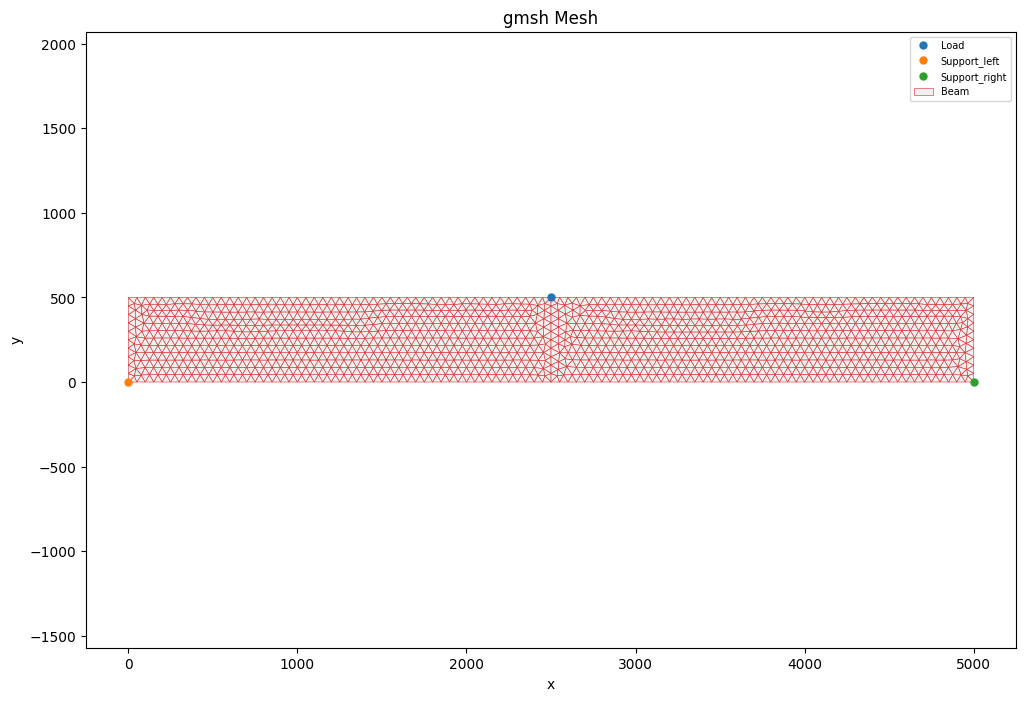

In [18]:
# %matplotlib widge
plot_gmsh_mesh(mesh,
               show_node_labels   = False,
               show_element_labels= False,
               show_node_points   = False,
            #    view_3d            = True,   elev= 45, azim= -45,
               figsize            = (12, 8))

In [19]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Assembly
K = lil_matrix((system_nDof, system_nDof))
for element in elements:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            K[i_global, j_global] += element.kg[i_local, j_local]
K = K.tocsr()

# Force vector
F = F_load.copy()

# DOF classification
dof_flags       = np.concatenate([node.restrain for node in node_map.values()])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

# Partitioning
Kff = K[free_dofs[:, None], free_dofs]
Kfr = K[free_dofs[:, None], restrained_dofs]
Krf = K[restrained_dofs[:, None], free_dofs]
Krr = K[restrained_dofs[:, None], restrained_dofs]

# Solution
ur = np.zeros(len(restrained_dofs))
uf = spsolve(Kff, F[free_dofs] - Kfr @ ur)

u = np.zeros(system_nDof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr = Krf @ uf + Krr @ ur
R  = np.zeros(system_nDof)
R[restrained_dofs] = Rr

In [20]:
# Reactions per node
for node in node_map.values():
    if any(r == 'r' for r in node.restrain):
        r = R[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}")

# Equilibrium check
total_applied_x  = np.sum(F[0::2])
total_applied_y  = np.sum(F[1::2])
total_reaction_x = np.sum(R[0::2])
total_reaction_y = np.sum(R[1::2])
print('--' * 50)
print(f"Applied X:  {total_applied_x:+.4f}   Reaction X: {total_reaction_x:+.4f}   Balance: {total_applied_x + total_reaction_x:.4e}")
print(f"Applied Y:  {total_applied_y:+.4f}   Reaction Y: {total_reaction_y:+.4f}   Balance: {total_applied_y + total_reaction_y:.4e}")

Node 1:  Rx=-0.000000  Ry=+49035.000000
Node 2:  Rx=+0.000000  Ry=+49035.000000
----------------------------------------------------------------------------------------------------
Applied X:  +0.0000   Reaction X: -0.0000   Balance: -5.1077e-08
Applied Y:  -98070.0000   Reaction Y: +98070.0000   Balance: 8.6759e-08


In [21]:
n_nodes    = len(node_map)
n_elements = len(elements)

# Prepare displacement, force and reaction arrays (3D format for Gmsh)
u_3d = np.zeros((n_nodes, 3))
F_3d = np.zeros((n_nodes, 3))
R_3d = np.zeros((n_nodes, 3))

for i, node in enumerate(node_map.values()):
    u_3d[i, 0] = u[node.idx[0]]
    u_3d[i, 1] = u[node.idx[1]]
    F_3d[i, 0] = F[node.idx[0]]
    F_3d[i, 1] = F[node.idx[1]]
    R_3d[i, 0] = R[node.idx[0]]
    R_3d[i, 1] = R[node.idx[1]]

# Node tags for Gmsh
node_tags = np.array([node.name for node in node_map.values()])

# Stress, strain and Von Mises
sigma_gmsh             = np.zeros((n_elements, 3))
epsilon_gmsh           = np.zeros((n_elements, 3))
sigma_principal_gmsh   = np.zeros((n_elements, 2))
epsilon_principal_gmsh = np.zeros((n_elements, 2))
von_mises_gmsh         = np.zeros(n_elements)
element_tags_list      = []

for i, element in enumerate(elements):
    results = element.get_results(u)
    sigma   = results['stress'].flatten()
    epsilon = results['strain'].flatten()

    sigma_gmsh[i, :]             = sigma
    epsilon_gmsh[i, :]           = epsilon
    sigma_principal_gmsh[i, :]   = results['principal_stress'].flatten()
    epsilon_principal_gmsh[i, :] = results['principal_strain'].flatten()

    sxx, syy, sxy     = sigma
    von_mises_gmsh[i] = np.sqrt(sxx**2 - sxx*syy + syy**2)
    element_tags_list.append(element.element_tag)

In [22]:

# VISUALIZE RESULTS IN GMSH


gmsh.initialize()
gmsh.open(output_file)

# Node tags already computed above
# node_tags = np.array([node.name for node in nodes_list])

# --- Nodal vector fields ---
# VectorType options:
# 1 → Line segments (simple lines)
# 2 → Arrows
# 3 → Pyramids
# 4 → 3D arrows
# 5 → Displacement (visually deforms mesh)
# 6 → Displacement with deformation

# view_disp_vec = add_node_data_view("Disp Vector", 
#                                     node_tags, 
#                                     u_3d, 
#                                     visible=False)
# u_mag = np.linalg.norm(u_3d, axis=1)


add_node_data_view("Displacements",
                   node_tags, 
                   u_3d,
                #    deformed_view=view_disp_vec, 
                   vector_type=5,
                   factor=10)

add_node_data_view("Applied Loads",
                   node_tags,
                   F_3d,
                   arrow_size_max=60,
                   arrow_size_min=20)

add_node_data_view("Reactions",
                   node_tags,
                   R_3d)

2

In [23]:
# Hide surface faces for better visualization
gmsh.option.setNumber("Mesh.SurfaceFaces", 0)

# --- Element-based stress fields ---
add_element_data_view("Stress Sxx", 
                      element_tags_list, 
                      sigma_gmsh[:, 0])

add_element_data_view("Stress Syy", 
                      element_tags_list,
                        sigma_gmsh[:, 1])

add_element_data_view("Stress Sxy", 
                      element_tags_list, 
                      sigma_gmsh[:, 2])

# --- Element-based strain fields ---
add_element_data_view("Strain Exx", 
                      element_tags_list, 
                      epsilon_gmsh[:, 0])

add_element_data_view("Strain Eyy", 
                      element_tags_list, 
                      epsilon_gmsh[:, 1])

add_element_data_view("Strain Exy",
                      element_tags_list, 
                      epsilon_gmsh[:, 2])

8

In [24]:
# --- Principal stresses ---
add_element_data_view("Principal Stress S1", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 0])

add_element_data_view("Principal Stress S2", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 1])

# --- Principal strains ---
add_element_data_view("Principal Strain E1", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 0])

add_element_data_view("Principal Strain E2", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 1])

12

In [25]:
# --- Von Mises stress ---
add_element_data_view("Von Mises Stress", 
                      element_tags_list, 
                      von_mises_gmsh)

13

In [26]:
# --- Nodal averaged stress fields ---
sxx_nodal = compute_nodal_average(  mesh, 
                                    element_tags_list, 
                                    sigma_gmsh[:, 0])
add_node_data_view("Sxx Nodal Averaged",    
                    node_tags, sxx_nodal)

# -----------------
syy_nodal = compute_nodal_average(  mesh, 
                                    element_tags_list, 
                                    sigma_gmsh[:, 1])
add_node_data_view("Syy Nodal Averaged",    
                    node_tags, syy_nodal)

# -----------------
sxy_nodal = compute_nodal_average(  mesh, 
                                    element_tags_list, 
                                    sigma_gmsh[:, 2])
add_node_data_view("Sxy Nodal Averaged",    
                    node_tags, sxy_nodal)

# -----------------
s1_nodal = compute_nodal_average(   mesh, 
                                    element_tags_list, 
                                    sigma_principal_gmsh[:, 0])
add_node_data_view("Principal Stress S1 Nodal Averaged", 
                    node_tags, s1_nodal)

# -----------------
s2_nodal = compute_nodal_average(   mesh, 
                                    element_tags_list, 
                                    sigma_principal_gmsh[:, 1])
add_node_data_view("Principal Stress S2 Nodal Averaged", 
                    node_tags, s2_nodal)

# -----------------
vm_nodal = compute_nodal_average(mesh, 
                                 element_tags_list, 
                                 von_mises_gmsh)
add_node_data_view("Von Mises Nodal Averaged",
                   node_tags, vm_nodal)

# -----------------
exx_nodal = compute_nodal_average(mesh, 
                                element_tags_list, 
                                epsilon_gmsh[:, 0])
add_node_data_view("Strain Exx Averaged", 
                    node_tags, exx_nodal)

# -----------------
# Open Gmsh GUI
gmsh.fltk.run()
gmsh.finalize()

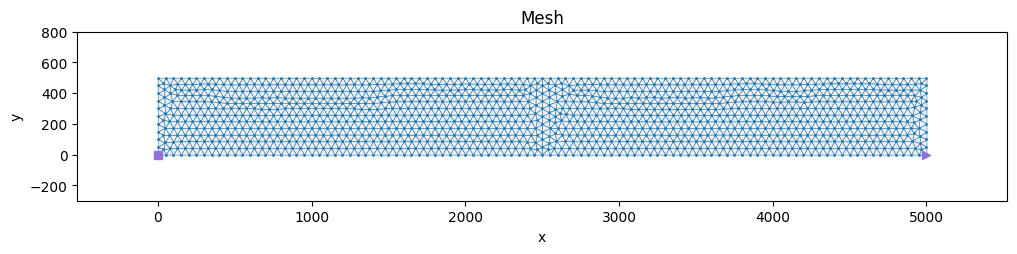

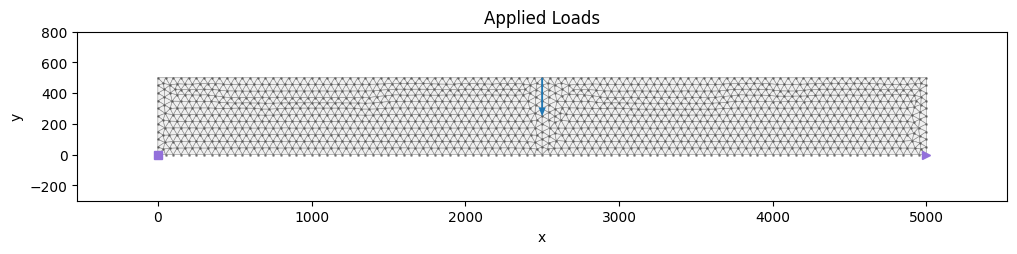

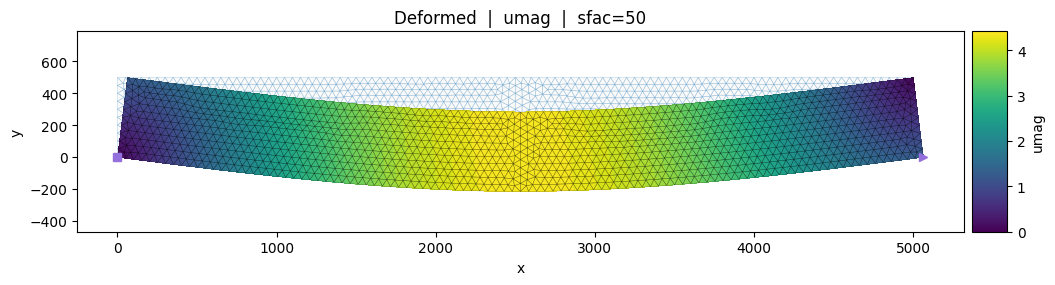

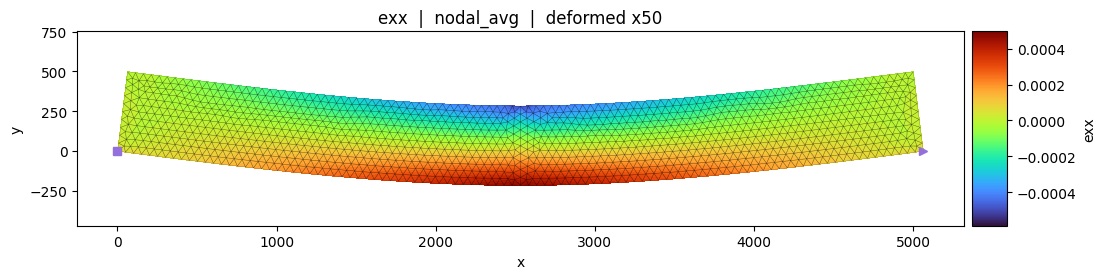

In [27]:
# Mesh
plot_mesh(
    nodes               = node_map.values(),
    elements            = elements,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Loads
plot_loads_2d(
    nodes               = node_map.values(),
    elements            = elements,
    F_load              = F_load,
    show_element_edges  = True,
    show_node_points    = True,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Deformed
plot_deformed(
    nodes               = node_map.values(),
    elements            = elements,
    u                   = u,
    component           = 'umag',   # 'ux', 'uy', 'umag'
    sfac                = 50,
    cmap                = 'viridis',
    limit               = None,
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Stress or Strain Field
plot_field_2d(
    nodes               = node_map.values(),
    elements            = elements,
    u                   = u,
    component           = 'exx',       # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy','e1','e2'
    result_type         = 'nodal_avg', # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 50,
    limit               = None,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

In [28]:
def get_node(node_map, u, tag=None, x=None, y=None):
    """
    Returns a node by tag or by closest position and prints its displacements.
    Provide either tag or (x, y), not both.
    """
    if tag is not None:
        node = node_map[tag]
    else:
        best_tag  = None
        best_dist = np.inf
        for t, n in node_map.items():
            dist = np.linalg.norm(n.coordinates - np.array([x, y]))
            if dist < best_dist:
                best_dist = dist
                best_tag  = t
        node = node_map[best_tag]

    d = u[node.idx]
    print(f"Node {node.name} at {node.coordinates}:  ux={d[0]:+.6f}  uy={d[1]:+.6f}")
    return node

# By tag
node = get_node(node_map, u , tag=3)
# By position
node = get_node(node_map, u, x=2500, y=500)

Node 3 at [5000.  500.]:  ux=+0.022850  uy=-0.044329
Node 6 at [2500.  500.]:  ux=+0.647906  uy=-4.365383


In [29]:
def get_element(elements, u, tag=None, x=None, y=None):
    """
    Returns an element by tag or by closest centroid position and prints its results.
    Provide either tag or (x, y), not both.
    """
    if tag is not None:
        elem = next((e for e in elements if e.element_tag == tag), None)
        if elem is None:
            print(f"Element tag={tag} not found.")
            return None
    else:
        best_elem = None
        best_dist = np.inf
        for e in elements:
            centroid = np.mean([n.coordinates for n in e.nodes], axis=0)
            dist     = np.linalg.norm(centroid - np.array([x, y]))
            if dist < best_dist:
                best_dist = dist
                best_elem = e
        elem = best_elem

    results  = elem.get_results(u)
    centroid = np.mean([n.coordinates for n in elem.nodes], axis=0)
    stress  = results['stress'].flatten()
    strain  = results['strain'].flatten()

    print(f"Element {elem.element_tag} at centroid {centroid}:")
    print(f"  stress : sxx={stress[0]:+.4f}  syy={stress[1]:+.4f}  sxy={stress[2]:+.4f}")
    print(f"  strain : exx={strain[0]:+.6f}  eyy={strain[1]:+.6f}  exy={strain[2]:+.6f}")

    return elem

# # By tag
# elem = get_element(elements, u, tag=10)

# By position
elem = get_element(elements, u, x=2500, y=0)

Element 2246 at centroid [2528.867513   12.200847]:
  stress : sxx=+9.5132  syy=-0.0551  sxy=-0.1365
  strain : exx=+0.000496  eyy=-0.000102  exy=-0.000017


## Opensees

In [30]:
# import openseespy.opensees as ops
import opensees as ops
import opsvis as opsv

ops.wipe()
ops.model('basicBuilder','-ndm',2,'-ndf',2)



         OpenSees -- Open System For Earthquake Engineering Simulation
                 Pacific Earthquake Engineering Research Center
                        Version 3.7.2 64-Bit


      (c) Copyright 1999-2016 The Regents of the University of California
                              All Rights Reserved
  (Copyright and Disclaimer @ http://www.berkeley.edu/OpenSees/copyright.html)


  *********** (o_O) OPENSEES (>'-')> Ladruno4ever *********** 3.7.2




In [31]:
# Nodes
for tag, (x, y, z) in mesh.nodes.items():
    ops.node(tag, x, y)

In [32]:
# Boundary conditions
for phys_id, condition in restrain_dictionary.items():
    if phys_id not in mesh.elements:
        continue
    for conn in mesh.elements[phys_id]['connectivity']:
        for tag in conn:
            ops.fix(tag, *[1 if r == 'r' else 0 for r in condition])

In [33]:
# Material
solidMaterialTag = 1

ops.nDMaterial('ElasticIsotropic', solidMaterialTag,
               fc_21.E,
               fc_21.nu,
               fc_21.rho)

In [34]:
# Elements
for phys_id, section in section_dictionary.items():
    if phys_id not in mesh.elements:
        continue
    group = mesh.elements[phys_id]
    for elem_tag, conn in zip(group['element_tags'], group['connectivity']):
        ops.element('tri31', elem_tag, *conn, section.thickness, 'PlaneStress', solidMaterialTag)

Tri31 - Written by Roozbeh G. Mikola and N.Sitar, UC Berkeley


<Axes: >

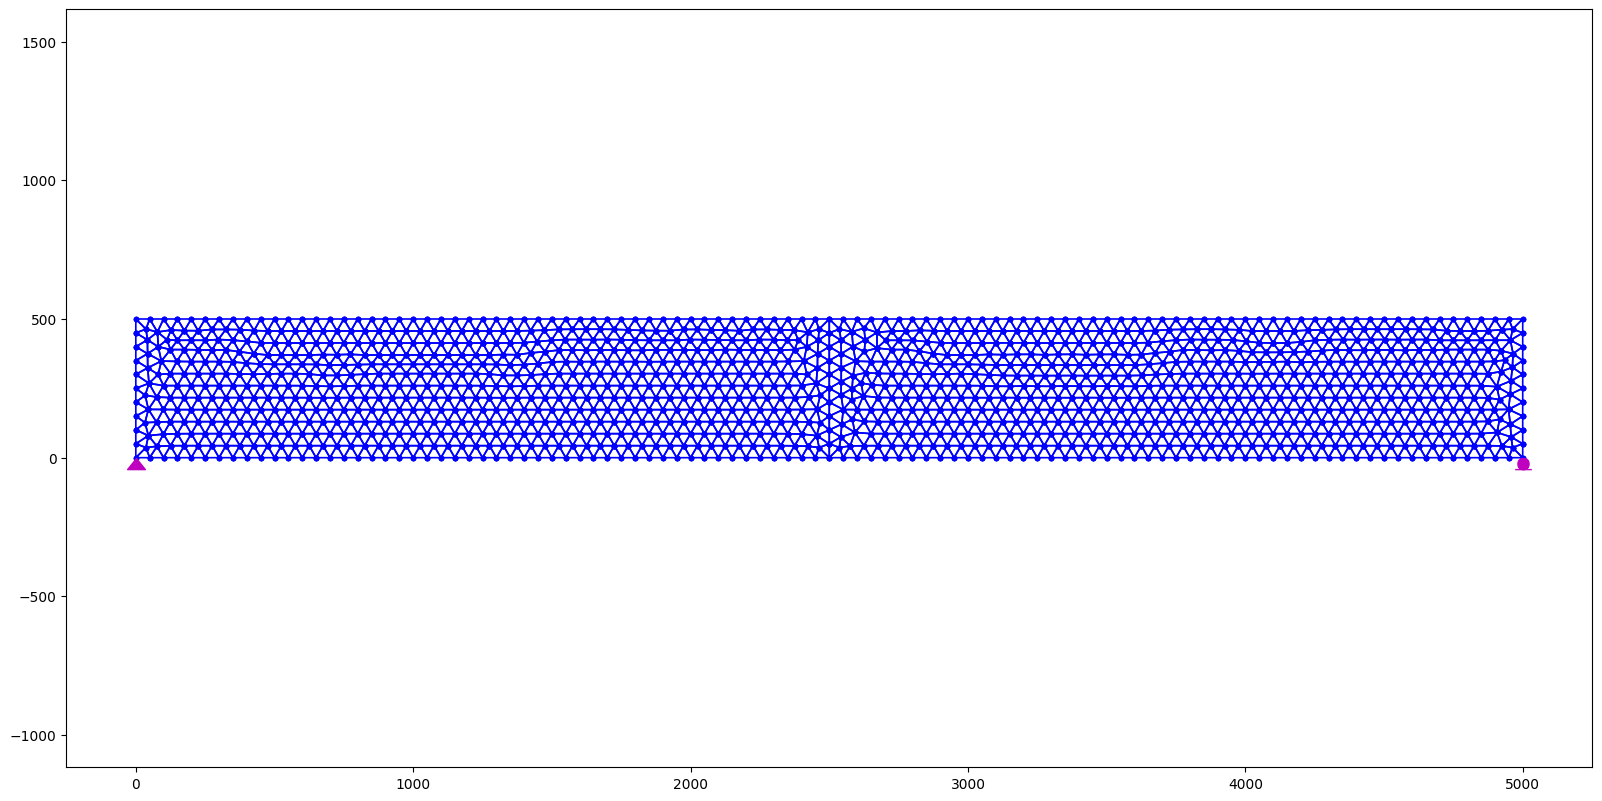

In [35]:
opsv.plot_model(node_labels=0, element_labels=0, fig_wi_he=(50,25))

In [36]:
# Loads
ts_tag      = 2
pattern_tag = 2
ops.timeSeries('Linear', ts_tag)
ops.pattern('Plain', pattern_tag, ts_tag)

for node in node_map.values():
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        ops.load(int(node.name), float(fx), float(fy))

In [37]:
NstepGravity=10
DGravity=1/NstepGravity

ops.system("FullGeneral")
ops.numberer("Plain")
ops.constraints("Plain")
ops.integrator("LoadControl", DGravity )
ops.test("NormUnbalance", 1.0e-6, 100 , 0)
ops.algorithm("Newton")
ops.analysis("Static")

ops.analyze(NstepGravity)

0

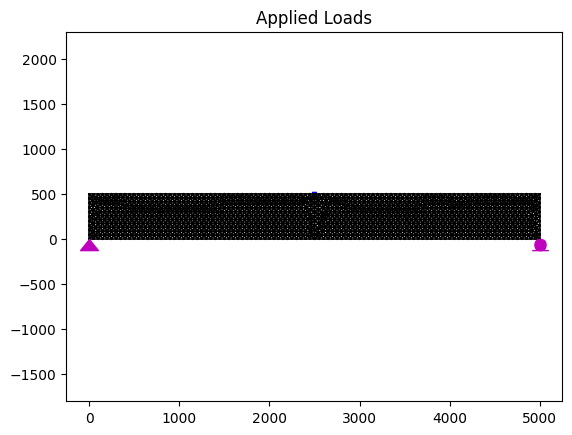

In [38]:
opsv.plot_loads_2d(sfac=0.1)
for txt in plt.gca().texts:
    txt.set_visible(False)
plt.title('Applied Loads')
plt.show()

10

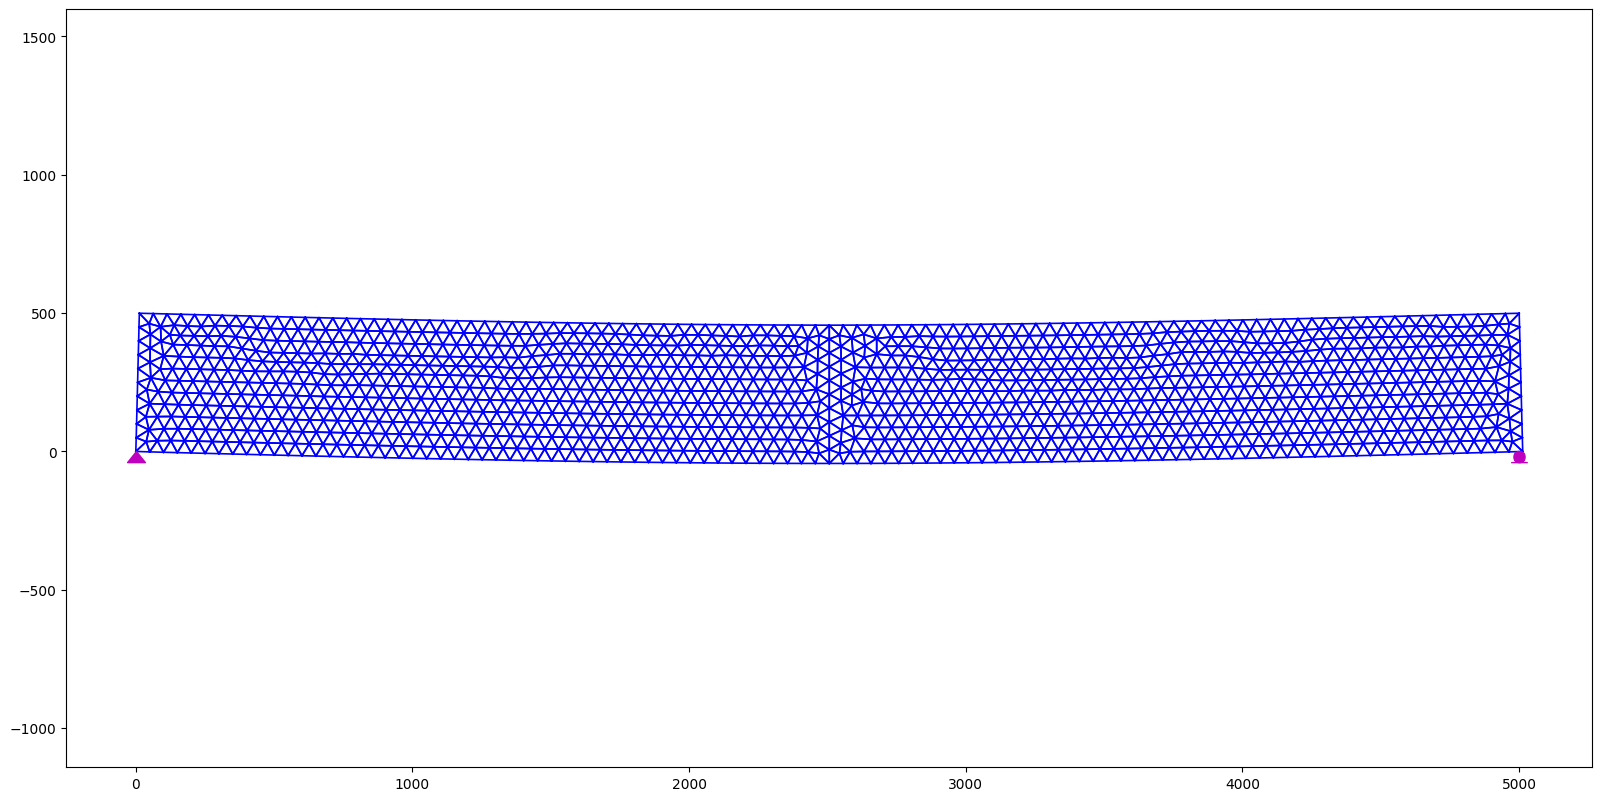

In [39]:
opsv.plot_defo(
    sfac=10,
    fig_wi_he=(50, 25),
    endDispFlag=True,
    unDefoFlag=0
)

Text(0.5, 1.0, 'sxx')

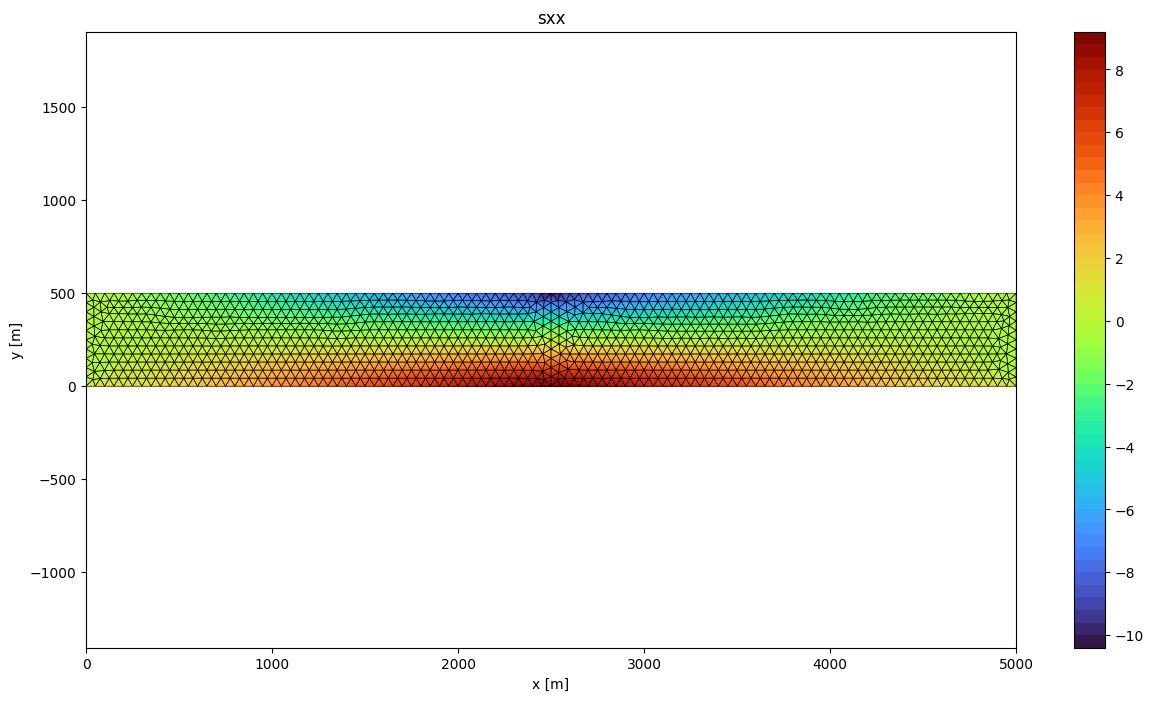

In [40]:
jstr = 'sxx'
# jstr = 'syy'
# jstr = 'sxy'
# jstr = 'vmis'
# jstr = 's1'
# jstr = 's2'
# jstr = 'angle'

plt.figure(figsize=(15, 8))
opsv.plot_stress(jstr)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title(f'{jstr}')